# Markov decision process

This week's methods are all built to solve __M__arkov __D__ecision __P__rocesses. In the broadest sense, an MDP is defined by how it changes states and how rewards are computed.

State transition is defined by $P(s' |s,a)$ - how likely are you to end at state $s'$ if you take action $a$ from state $s$. Now there's more than one way to define rewards, but we'll use $r(s,a,s')$ function for convenience.

_This notebook is inspired by the awesome_ [CS294](https://github.com/berkeleydeeprlcourse/homework/blob/36a0b58261acde756abd55306fbe63df226bf62b/hw2/HW2.ipynb) _by Berkeley_

For starters, let's define a simple MDP from this picture:

<img src="https://upload.wikimedia.org/wikipedia/commons/a/ad/Markov_Decision_Process.svg" width="400px" alt="Diagram by Waldoalvarez via Wikimedia Commons, CC BY-SA 4.0"/>

In [1]:
import numpy as np
import matplotlib as plt

from time import sleep
from mdp import MDP, has_graphviz, FrozenLakeEnv
from IPython.display import display, clear_output

%matplotlib inline

In [2]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

mdp = MDP(transition_probs, rewards, initial_state='s0')

We can now use MDP just as any other gym environment:

In [3]:
print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print('next_state = %s, reward = %s, done = %s' % (next_state, reward, done))

initial state = s0
next_state = s2, reward = 0.0, done = False


but it also has other methods that you'll need for Value Iteration

In [4]:
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ",
      mdp.get_transition_prob('s1', 'a0', 's0'))

mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


### Optional: Visualizing MDPs

You can also visualize any MDP with the drawing fuction donated by [neer201](https://github.com/neer201).

You have to install graphviz for system and for python. For ubuntu just run:

1. `sudo apt-get install graphviz`
2. `pip install graphviz`
3. restart the notebook

For windows this might work: `conda install -c conda-forge python-graphviz`. However, you can ignore this part alltogether and use the standard vizualization.

In [5]:
print("Graphviz available:", has_graphviz)

Graphviz available: True


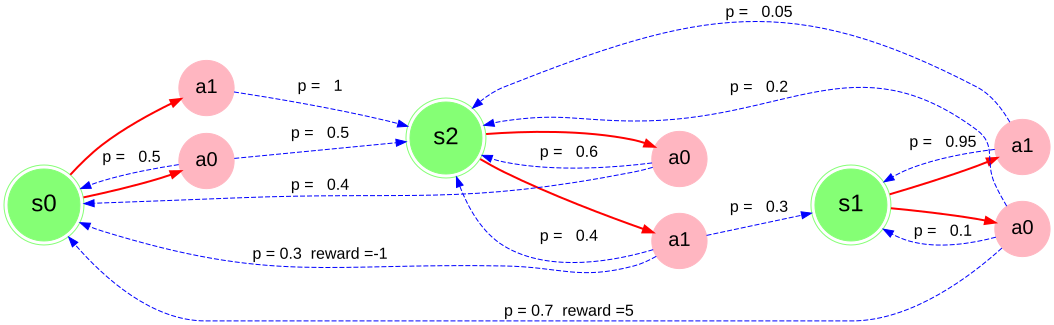

In [6]:
if has_graphviz:
    from mdp import plot_graph, plot_graph_with_state_values, \
        plot_graph_optimal_strategy_and_state_values

    display(plot_graph(mdp))

# Value Iteration (up to 1 point)

Now let's build something to solve this MDP. The simplest algorithm so far is __V__alue __I__teration

Here's the pseudo-code for VI:

---

`1.` Initialize $V^{(0)}(s)=0$, for all $s$

`2.` For $i=0, 1, 2, \dots$
 
`3.` $ \quad V_{(i+1)}(s) = \max\limits_a \sum\limits_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$, for all $s$

---

First, let's write a function to compute the state-action value function $Q^*$, defined as follows

$$Q_i(s, a) = \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$$


In [7]:
# added decorator for function time estiation

import time
def timing_decorator(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        elapsed_time = end_time - start_time
        print(f"Время выполнения функции {func.__name__}: {elapsed_time} секунд")
        return result
    return wrapper

In [12]:
%%writefile mdp_get_action_value.py
def get_action_value(mdp, state_values, state, action, gamma):
    """ 
    Computes Q(s,a) as in formula above
    for all the proceeding states which we can go from the current
    we accumulate rewards + v_i which we'll count later (it's a state value in fact for all states)
    """

    next_states = mdp.get_next_states(action=action, state=state)
    q_i = 0
    for next_state in next_states:
        v_i = state_values[next_state]
        r = mdp.get_reward(state=state, action=action, next_state=next_state)
        p = mdp.get_transition_prob(action=action, next_state=next_state, state=state)
#         print(next_state, v_i, r, p)
        q_i = q_i + p * (r + gamma * v_i)
    return q_i

Overwriting mdp_get_action_value.py


In [13]:
test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

Using $Q(s,a)$ we can now define the "next" V(s) for value iteration.
 $$V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \max_a Q_i(s,a)$$

In [14]:
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ",
      mdp.get_transition_prob('s1', 'a0', 's0'))

mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


In [15]:
def get_new_state_value(mdp, state_values, state, gamma):
    """ Computes next V(s) as in formula above. Please do not change state_values in process. """
    if mdp.is_terminal(state):
        return 0
    else:
        state_action_values = []
        for action in mdp.get_possible_actions(state):
            action_value = get_action_value(mdp, state_values, state, action, gamma)
            state_action_values.append(action_value)
#             print(state_action_values)
    
    return max(state_action_values)

In [16]:
test_Vs_copy = dict(test_Vs)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's0', 0.9), 1.8)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's2', 0.9), 1.08)
assert test_Vs == test_Vs_copy, "please do not change state_values in get_new_state_value"

Finally, let's combine everything we wrote into a working value iteration algo.

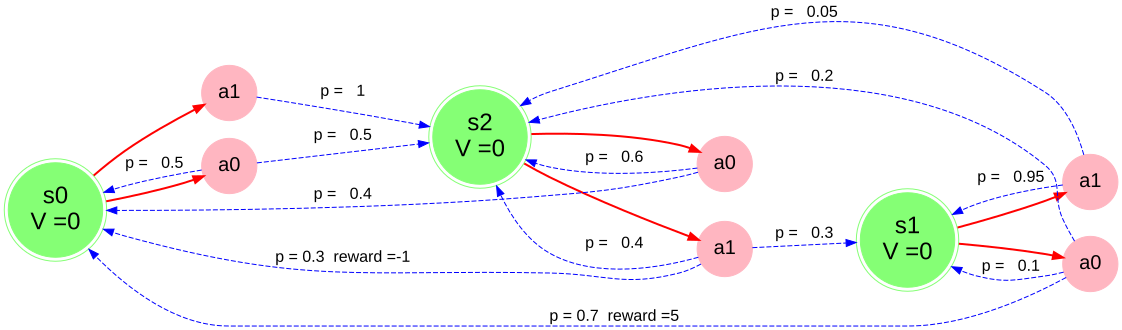

iter    0   |   diff: 3.50000   |   V(s0) = 0.000   V(s1) = 0.000   V(s2) = 0.000
iter    1   |   diff: 0.64500   |   V(s0) = 0.000   V(s1) = 3.500   V(s2) = 0.000
iter    2   |   diff: 0.58050   |   V(s0) = 0.000   V(s1) = 3.815   V(s2) = 0.645
iter    3   |   diff: 0.43582   |   V(s0) = 0.581   V(s1) = 3.959   V(s2) = 0.962
iter    4   |   diff: 0.30634   |   V(s0) = 0.866   V(s1) = 4.395   V(s2) = 1.272
iter    5   |   diff: 0.27571   |   V(s0) = 1.145   V(s1) = 4.670   V(s2) = 1.579
iter    6   |   diff: 0.24347   |   V(s0) = 1.421   V(s1) = 4.926   V(s2) = 1.838
iter    7   |   diff: 0.21419   |   V(s0) = 1.655   V(s1) = 5.169   V(s2) = 2.075
iter    8   |   diff: 0.19277   |   V(s0) = 1.868   V(s1) = 5.381   V(s2) = 2.290
iter    9   |   diff: 0.17327   |   V(s0) = 2.061   V(s1) = 5.573   V(s2) = 2.481
iter   10   |   diff: 0.15569   |   V(s0) = 2.233   V(s1) = 5.746   V(s2) = 2.654
iter   11   |   diff: 0.14012   |   V(s0) = 2.389   V(s1) = 5.902   V(s2) = 2.810
iter   12   |   

In [17]:
# parameters
gamma = 0.9            # discount for MDP
num_iter = 100         # maximum iterations, excluding initialization
# stop VI if new values are this close to old values (or closer)
min_difference = 0.001

# initialize V(s)
state_values = {s: 0 for s in mdp.get_all_states()}

if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

for i in range(num_iter):
    
    # Compute new state values using the functions you defined above.
    # It must be a dict {state : float V_new(state)}
    new_state_values = {}
    for state in mdp.get_all_states():
        new_state_values[state] = get_new_state_value(mdp, state_values, state, gamma)

    assert isinstance(new_state_values, dict)

    # Compute difference
    diff = max(abs(new_state_values[s] - state_values[s])
               for s in mdp.get_all_states())
    print("iter %4i   |   diff: %6.5f   |   " % (i, diff), end="")
    print('   '.join("V(%s) = %.3f" % (s, v) for s, v in state_values.items()))
    state_values = new_state_values

    if diff < min_difference:
        print("Terminated")
        break

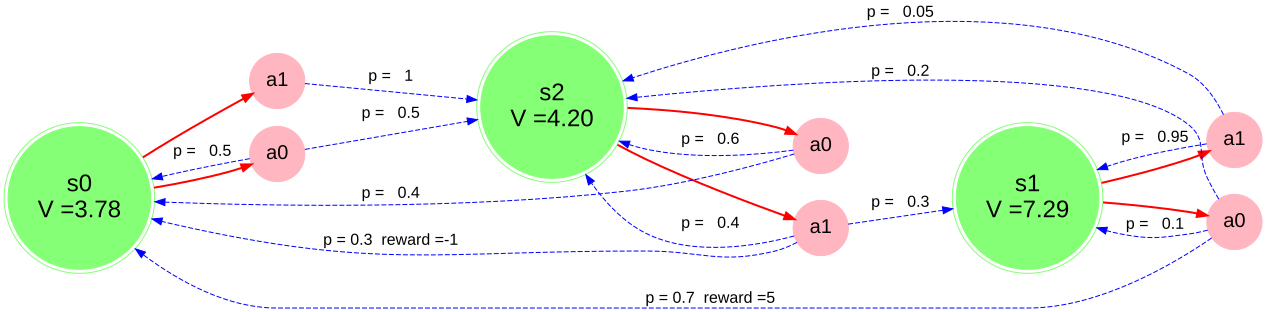

In [18]:
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

In [19]:
print("Final state values:", state_values)

assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01

Final state values: {'s0': 3.7810348735476405, 's1': 7.294006423867229, 's2': 4.202140275227048}


Now let's use those $V^{*}(s)$ to find optimal actions in each state

 $$\pi^*(s) = \underset{a}{\operatorname{argmax}} \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \underset{a}{\operatorname{argmax}} Q_i(s,a)$$
 
The only difference vs V(s) is that here we take not max but argmax: find action such with maximum Q(s,a).

In [20]:
def get_optimal_action(mdp, state_values, state, gamma=0.9):
    """ Finds optimal action using formula above. """
    if mdp.is_terminal(state):
        return None
    else:
        state_action_values = []
        for action in mdp.get_possible_actions(state):
            action_value = get_action_value(mdp, state_values, state, action, gamma)
            state_action_values.append(action_value)
        optimal_action = mdp.get_possible_actions(state)[np.argmax(state_action_values)]
    return optimal_action

In [21]:
assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'

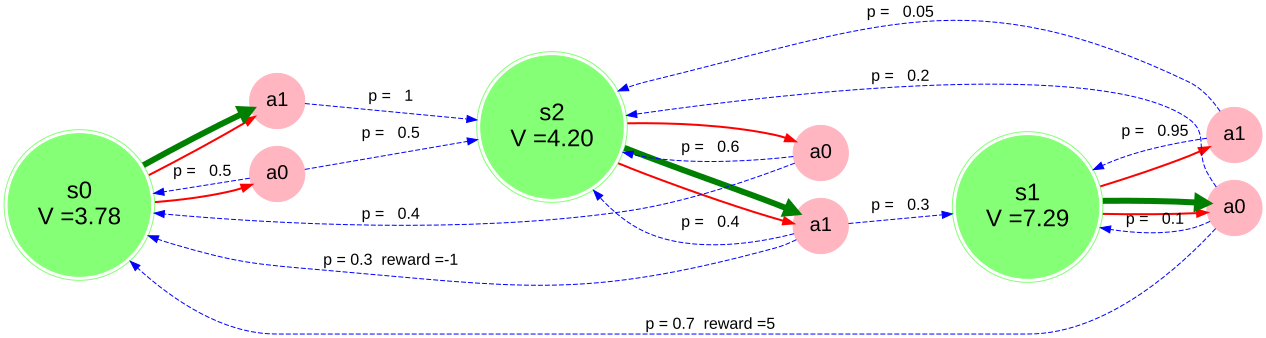

In [22]:
if has_graphviz:
    try:
        display(plot_graph_optimal_strategy_and_state_values(mdp, state_values))
    except ImportError:
        raise ImportError("Run the cell that starts with \"%%writefile mdp_get_action_value.py\"")

In [23]:
# Measure agent's average reward

s = mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
    rewards.append(r)

print("average reward: ", np.mean(rewards))

assert(0.40 < np.mean(rewards) < 0.55)

average reward:  0.4558


### Frozen lake

In [24]:
mdp = FrozenLakeEnv(slip_chance=0)

mdp.render()

*FFF
FHFH
FFFH
HFFG



In [25]:
@timing_decorator
def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ performs num_iter value iteration steps starting from state_values. Same as before but in a function """
    state_values = state_values or {s: 0 for s in mdp.get_all_states()}

    print('START VALUE ITERATION LOOP')
    for i in range(num_iter):
        new_state_values = {}
        for state in mdp.get_all_states():
            # Compute new state values using the functions you defined above. It must be a dict {state : new_V(state)}
            new_state_values[state] = get_new_state_value(mdp, state_values, state, gamma)

        assert isinstance(new_state_values, dict)

        # Compute difference
        diff = max(abs(new_state_values[s] - state_values[s])
                   for s in mdp.get_all_states())

        print("iter %4i   |   diff: %6.5f   |   V(start): %.3f " %
              (i, diff, new_state_values[mdp._initial_state]))

        state_values = new_state_values
        if diff < min_difference:
            break

    return state_values

In [26]:
state_values = value_iteration(mdp)

START VALUE ITERATION LOOP
iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 
Время выполнения функции value_iteration: 0.0016651153564453125 секунд


In [27]:
s = mdp.reset()
mdp.render()
for t in range(100):
    a = get_optimal_action(mdp, state_values, s, gamma)
    print(a, end='\n\n')
    s, r, done, _ = mdp.step(a)
    mdp.render()
    if done:
        break

*FFF
FHFH
FFFH
HFFG

down

SFFF
*HFH
FFFH
HFFG

down

SFFF
FHFH
*FFH
HFFG

right

SFFF
FHFH
F*FH
HFFG

down

SFFF
FHFH
FFFH
H*FG

right

SFFF
FHFH
FFFH
HF*G

right

SFFF
FHFH
FFFH
HFF*



### Let's visualize!

It's usually interesting to see what your algorithm actually learned under the hood. To do so, we'll plot state value functions and optimal actions at each VI step.

In [28]:
def draw_policy(mdp, state_values, Pi = None):
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    if not Pi:
        Pi = {s: get_optimal_action(mdp, state_values, s, gamma) for s in states}
    plt.imshow(V.reshape(w, h), cmap='gray', interpolation='none', clim=(0, 1))
    ax = plt.gca()
    ax.set_xticks(np.arange(h)-.5)
    ax.set_yticks(np.arange(w)-.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    Y, X = np.mgrid[0:4, 0:4]
    a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (0, 1)}
    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()),
                     color='g', size=12,  verticalalignment='center',
                     horizontalalignment='center', fontweight='bold')
            a = Pi[y, x]
            if a is None:
                continue
            u, v = a2uv[a]
            plt.arrow(x, y, u*.3, -v*.3, color='m',
                      head_width=0.1, head_length=0.1)
    plt.grid(color='b', lw=2, ls='-')
    plt.show()

after iteration 0
START VALUE ITERATION LOOP
iter    0   |   diff: 1.00000   |   V(start): 0.000 
Время выполнения функции value_iteration: 0.00026798248291015625 секунд


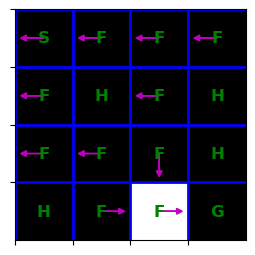

after iteration 1
START VALUE ITERATION LOOP
iter    0   |   diff: 0.90000   |   V(start): 0.000 
Время выполнения функции value_iteration: 0.0002949237823486328 секунд


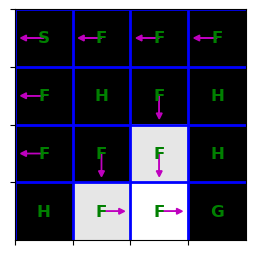

after iteration 2
START VALUE ITERATION LOOP
iter    0   |   diff: 0.81000   |   V(start): 0.000 
Время выполнения функции value_iteration: 0.00010585784912109375 секунд


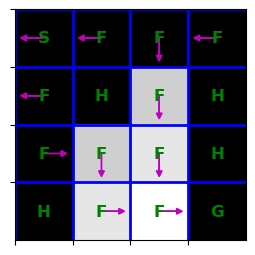

after iteration 3
START VALUE ITERATION LOOP
iter    0   |   diff: 0.72900   |   V(start): 0.000 
Время выполнения функции value_iteration: 0.0002930164337158203 секунд


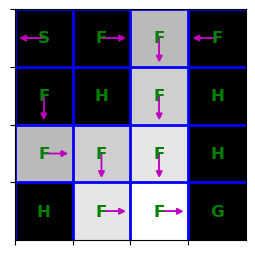

after iteration 4
START VALUE ITERATION LOOP
iter    0   |   diff: 0.65610   |   V(start): 0.000 
Время выполнения функции value_iteration: 0.00010609626770019531 секунд


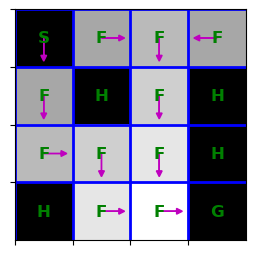

after iteration 5
START VALUE ITERATION LOOP
iter    0   |   diff: 0.59049   |   V(start): 0.590 
Время выполнения функции value_iteration: 0.00010132789611816406 секунд


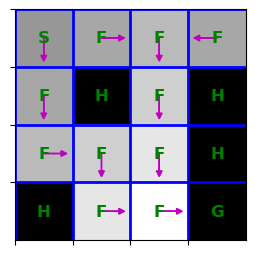

after iteration 6
START VALUE ITERATION LOOP
iter    0   |   diff: 0.00000   |   V(start): 0.590 
Время выполнения функции value_iteration: 0.0001049041748046875 секунд


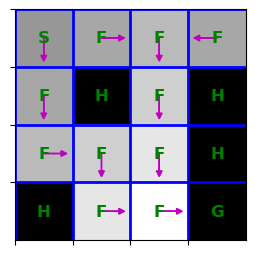

after iteration 7
START VALUE ITERATION LOOP
iter    0   |   diff: 0.00000   |   V(start): 0.590 
Время выполнения функции value_iteration: 0.00010132789611816406 секунд


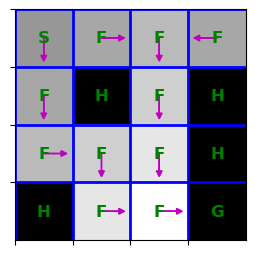

after iteration 8
START VALUE ITERATION LOOP
iter    0   |   diff: 0.00000   |   V(start): 0.590 
Время выполнения функции value_iteration: 0.00010228157043457031 секунд


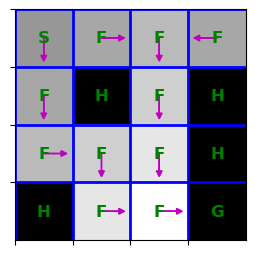

after iteration 9
START VALUE ITERATION LOOP
iter    0   |   diff: 0.00000   |   V(start): 0.590 
Время выполнения функции value_iteration: 9.989738464355469e-05 секунд


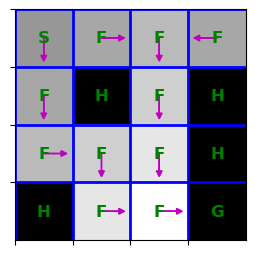

In [29]:
import matplotlib.pyplot as plt

state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(10):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
# please ignore iter 0 at each step

after iteration 29
START VALUE ITERATION LOOP
iter    0   |   diff: 0.00000   |   V(start): 0.198 
Время выполнения функции value_iteration: 0.0023200511932373047 секунд


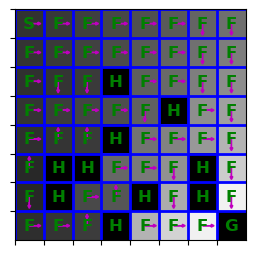

In [30]:
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(30):
    clear_output(True)
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
    sleep(0.5)
# please ignore iter 0 at each step

Massive tests

In [31]:
mdp = FrozenLakeEnv(slip_chance=0)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Well done!")

START VALUE ITERATION LOOP
iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 
Время выполнения функции value_iteration: 0.004598140716552734 секунд
average reward:  1.0
Well done!


In [32]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Well done!")

START VALUE ITERATION LOOP
iter    0   |   diff: 0.90000   |   V(start): 0.000 
iter    1   |   diff: 0.72900   |   V(start): 0.000 
iter    2   |   diff: 0.62330   |   V(start): 0.000 
iter    3   |   diff: 0.50487   |   V(start): 0.000 
iter    4   |   diff: 0.40894   |   V(start): 0.000 
iter    5   |   diff: 0.34868   |   V(start): 0.349 
iter    6   |   diff: 0.06529   |   V(start): 0.410 
iter    7   |   diff: 0.05832   |   V(start): 0.468 
iter    8   |   diff: 0.01139   |   V(start): 0.480 
iter    9   |   diff: 0.00764   |   V(start): 0.487 
iter   10   |   diff: 0.00164   |   V(start): 0.489 
iter   11   |   diff: 0.00094   |   V(start): 0.490 
iter   12   |   diff: 0.00022   |   V(start): 0.490 
iter   13   |   diff: 0.00011   |   V(start): 0.490 
iter   14   |   diff: 0.00003   |   V(start): 0.490 
iter   15   |   diff: 0.00001   |   V(start): 0.490 
iter   16   |   diff: 0.00000   |   V(start): 0.490 
Время выполнения функции value_iteration: 0.002529621124267578 секунд
av

In [33]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.25)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.7)
print("Well done!")

START VALUE ITERATION LOOP
iter    0   |   diff: 0.75000   |   V(start): 0.000 
iter    1   |   diff: 0.50625   |   V(start): 0.000 
iter    2   |   diff: 0.39867   |   V(start): 0.000 
iter    3   |   diff: 0.26910   |   V(start): 0.000 
iter    4   |   diff: 0.18164   |   V(start): 0.000 
iter    5   |   diff: 0.14013   |   V(start): 0.140 
iter    6   |   diff: 0.07028   |   V(start): 0.199 
iter    7   |   diff: 0.06030   |   V(start): 0.260 
iter    8   |   diff: 0.02594   |   V(start): 0.285 
iter    9   |   diff: 0.01918   |   V(start): 0.305 
iter   10   |   diff: 0.00858   |   V(start): 0.313 
iter   11   |   diff: 0.00560   |   V(start): 0.319 
iter   12   |   diff: 0.00260   |   V(start): 0.321 
iter   13   |   diff: 0.00159   |   V(start): 0.323 
iter   14   |   diff: 0.00076   |   V(start): 0.324 
iter   15   |   diff: 0.00045   |   V(start): 0.324 
iter   16   |   diff: 0.00022   |   V(start): 0.324 
iter   17   |   diff: 0.00012   |   V(start): 0.325 
iter   18   |   dif

In [34]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Well done!")

START VALUE ITERATION LOOP
iter    0   |   diff: 0.80000   |   V(start): 0.000 
iter    1   |   diff: 0.57600   |   V(start): 0.000 
iter    2   |   diff: 0.41472   |   V(start): 0.000 
iter    3   |   diff: 0.29860   |   V(start): 0.000 
iter    4   |   diff: 0.24186   |   V(start): 0.000 
iter    5   |   diff: 0.19349   |   V(start): 0.000 
iter    6   |   diff: 0.15325   |   V(start): 0.000 
iter    7   |   diff: 0.12288   |   V(start): 0.000 
iter    8   |   diff: 0.09930   |   V(start): 0.000 
iter    9   |   diff: 0.08037   |   V(start): 0.000 
iter   10   |   diff: 0.06426   |   V(start): 0.000 
iter   11   |   diff: 0.05129   |   V(start): 0.000 
iter   12   |   diff: 0.04330   |   V(start): 0.000 
iter   13   |   diff: 0.03802   |   V(start): 0.033 
iter   14   |   diff: 0.03332   |   V(start): 0.058 
iter   15   |   diff: 0.02910   |   V(start): 0.087 
iter   16   |   diff: 0.01855   |   V(start): 0.106 
iter   17   |   diff: 0.01403   |   V(start): 0.120 
iter   18   |   dif

# Policy Iteration (up to 1 points)

Let's implement exact policy iteration (PI), which has the following pseudocode:

---
Initialize $\pi_0$   `// random or fixed action`

For $n=0, 1, 2, \dots$
- Compute the state-value function $V^{\pi_{n}}$
- Using $V^{\pi_{n}}$, compute the state-action-value function $Q^{\pi_{n}}$
- Compute new policy $\pi_{n+1}(s) = \underset{a}{\operatorname*{argmax}} Q^{\pi_{n}}(s,a)$
---

Unlike VI, policy iteration has to maintain a policy - chosen actions from all states - and estimate $V^{\pi_{n}}$ based on this policy. It only changes policy once values converged.


Below are a few helpers that you may or may not use in your implementation.

In [35]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

mdp = MDP(transition_probs, rewards, initial_state='s0')

Let's write a function called `compute_vpi` that computes the state-value function $V^{\pi}$ for an arbitrary policy $\pi$.

Unlike VI, this time you must find the exact solution, not just a single iteration.

Recall that $V^{\pi}$ satisfies the following linear equation:
$$V^{\pi}(s) = \sum_{s'} P(s,\pi(s),s')[ R(s,\pi(s),s') + \gamma V^{\pi}(s')]$$

You'll have to solve a linear system in your code. (Find an exact solution, e.g., with `np.linalg.solve` or fixed-point iteration method.)

In [36]:
def compute_vpi_matrix_form(mdp, policy, gamma):
    """
    Computes V^pi(s) FOR ALL STATES under given policy.
    :param policy: a dict of currently chosen actions {s : a}
    :returns: a dict {state : V^pi(state) for all states}
    """
    probs = np.zeros((mdp.n_states, mdp.n_states))
    rewards = np.zeros((mdp.n_states, mdp.n_states))
    
    dic_state_to_index = {s: i for i, s in enumerate(mdp.get_all_states())}
    dic_index_to_state = {i: s for i, s in enumerate(mdp.get_all_states())}
    
    for state in sorted(mdp.get_all_states()):
        if mdp.is_terminal(state):
            continue
        
        action = policy[state]

        for next_state in sorted(mdp.get_next_states(state, action)):
            state_i, next_state_i = dic_state_to_index[state], dic_state_to_index[next_state]
            probs[state_i][next_state_i] = mdp.get_transition_prob(state, action, next_state)
#             print(f"state - {state} next - {next_state} reward - {mdp.get_reward(state, action, next_state)}")
            rewards[state_i][next_state_i] = mdp.get_reward(state, action, next_state)
    
    x = np.eye(mdp.n_states) - probs * gamma
    y = np.sum(probs * rewards, axis=1)
    V = np.linalg.solve(x, y)

#     print(f'X___________ {x}')
#     print(f'Y___________ {y}')
#     print(f'this is V {V}')
    return {dic_index_to_state[i]: v for i, v in enumerate(V)}

In [37]:
# def compute_vpi_simple_form(mdp, policy, gamma):
#     """
#     ПОПЫТАЛСЯ НАПИСАТЬ СНАЧАЛА БЕЗ МАТРИЦ, НО ТУТ ГДЕ-ТО ОШИБКА, ПОЭТОМУ ПРОСТО ОСТАВИЛ ЭТУ ФУНКЦИЮ,
#     ПОТОМ ЕЩЕ ПОСМОТРЮ
    
#     Computes V^pi(s) FOR ALL STATES under given policy.
#     :param policy: a dict of currently chosen actions {s : a}
#     :returns: a dict {state : V^pi(state) for all states}
#     """
#     # YOUR CODE HERE
#     dic_state_to_index = {s: i for i, s in enumerate(mdp.get_all_states())}
#     dic_index_to_state = {i: s for i, s in enumerate(mdp.get_all_states())}
    
#     xs, vs = np.zeros((mdp.n_states, mdp.n_states)), np.zeros(mdp.n_states)
#     for state in sorted(mdp.get_all_states()):
#         if mdp.is_terminal(state):
#             continue
#         vi = 0
#         state_index = dic_state_to_index[state]
#         xs[state_index][state_index] = 1 - mdp.get_transition_prob(state, policy[state], state) * gamma
#         for next_state in sorted(mdp.get_next_states(state, policy[state])):
#             if next_state == state: continue
#             next_state_index = dic_state_to_index[next_state]    
# #             print(f'xs element {-mdp.get_transition_prob(state, policy[state], next_state) * gamma}')
#             xs[state_index, next_state_index] = -mdp.get_transition_prob(state, policy[state], next_state) * gamma
            
#             prob = mdp.get_transition_prob(state, policy[state], next_state) 
#             reward = mdp.get_reward(state, policy[state], next_state)
#             vi += prob * reward
#         vs[state_index] = vi

# #     print(f'матрица xs -  {xs}')
# #     print(f'определитель xs {np.linalg.det(xs)}')
    
#     ans = np.linalg.solve(xs, vs)
    
#     return {dic_index_to_state[i]: v for i, v in enumerate(ans)}

In [38]:
test_policy = {s: np.random.choice(
    mdp.get_possible_actions(s)) for s in mdp.get_all_states()}
# print(test_policy)

new_vpi = compute_vpi_matrix_form(mdp, test_policy, gamma)

assert type(new_vpi) is dict, "compute_vpi must return a dict {state : V^pi(state) for all states}"

Once we've got new state values, it's time to update our policy.

In [39]:
def compute_new_policy(mdp, vpi, gamma):
    """
    Computes new policy as argmax of state values
    :param vpi: a dict {state : V^pi(state) for all states}
    :returns: a dict {state : optimal action for all states}
    """
    optimal_actions = {}
    
    for state in mdp.get_all_states():
        if mdp.is_terminal(state):
            optimal_actions[state] = None
            continue
        
        action_values = {}
#         print(f'current_state {state}possible_actions {mdp.get_possible_actions(state)}')
        
        for action in mdp.get_possible_actions(state):
            
            action_value = 0
            for next_state in mdp.get_next_states(state, action):
                prob = mdp.get_transition_prob(state, action, next_state)
                state_value = vpi[next_state]
                reward = mdp.get_reward(state, action, next_state)
                action_value = action_value + prob * (reward + gamma * state_value)
            action_values[action] = action_value
        
#         print(f'action_values {action_values}')
        optimal_actions[state] = max(action_values, key=action_values.get)

#         print(f'optimal actions : {optimal_actions}')
            
    return optimal_actions

In [40]:
new_policy = compute_new_policy(mdp, new_vpi, gamma)

assert type(
    new_policy) is dict, "compute_new_policy must return a dict {state : optimal action for all states}"

__Main loop__

In [41]:
@timing_decorator
def policy_iteration(mdp, policy=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ 
    Run the policy iteration loop for num_iter iterations or till difference between V(s) is below min_difference.
    If policy is not given, initialize it at random.
    """
    if not policy:
        policy = {state: np.random.choice(mdp.get_possible_actions(state)) if not mdp.is_terminal(state) else None\
                  for state in mdp.get_all_states()}
    
    vpi = {state:0 for state in mdp.get_all_states()}
    
    print('START POLICY ITERATION LOOP')
    for i in range(num_iter):
        new_vpi = compute_vpi_matrix_form(mdp, policy, gamma)
        
        diff = max(abs(vpi[state] - new_vpi[state])
                   for state in mdp.get_all_states())
                    
        new_policy = compute_new_policy(mdp, new_vpi, gamma)
        
        vpi = new_vpi
        policy = new_policy
        print("iter %4i   |   diff: %6.5f   |   V(start): %.3f " %
              (i, diff, vpi[mdp._initial_state]))

        if diff < min_difference:
            print('Terminated')
            break
        
    return vpi, policy

__Your PI Results__

<font size=5 color=green> CUSTOM MDP

In [42]:
# < Compare PI and VI on the custom MDP, then on small & large FrozenLake >

state_values_value_iter = value_iteration(mdp)
state_values_policy_iter = policy_iteration(mdp)

START VALUE ITERATION LOOP
iter    0   |   diff: 3.50000   |   V(start): 0.000 
iter    1   |   diff: 0.64500   |   V(start): 0.000 
iter    2   |   diff: 0.58050   |   V(start): 0.581 
iter    3   |   diff: 0.43582   |   V(start): 0.866 
iter    4   |   diff: 0.30634   |   V(start): 1.145 
iter    5   |   diff: 0.27571   |   V(start): 1.421 
iter    6   |   diff: 0.24347   |   V(start): 1.655 
iter    7   |   diff: 0.21419   |   V(start): 1.868 
iter    8   |   diff: 0.19277   |   V(start): 2.061 
iter    9   |   diff: 0.17327   |   V(start): 2.233 
iter   10   |   diff: 0.15569   |   V(start): 2.389 
iter   11   |   diff: 0.14012   |   V(start): 2.529 
iter   12   |   diff: 0.12610   |   V(start): 2.655 
iter   13   |   diff: 0.11348   |   V(start): 2.769 
iter   14   |   diff: 0.10213   |   V(start): 2.871 
iter   15   |   diff: 0.09192   |   V(start): 2.963 
iter   16   |   diff: 0.08272   |   V(start): 3.045 
iter   17   |   diff: 0.07445   |   V(start): 3.120 
iter   18   |   dif

<font size=5 color=green> FROZEN LAKE (SMALL)

START VALUE ITERATION LOOP
iter    0   |   diff: 0.90000   |   V(start): 0.000 
iter    1   |   diff: 0.76950   |   V(start): 0.000 
iter    2   |   diff: 0.69447   |   V(start): 0.000 
iter    3   |   diff: 0.59378   |   V(start): 0.000 
iter    4   |   diff: 0.50768   |   V(start): 0.000 
iter    5   |   diff: 0.45691   |   V(start): 0.457 
iter    6   |   diff: 0.09031   |   V(start): 0.542 
iter    7   |   diff: 0.08515   |   V(start): 0.627 
iter    8   |   diff: 0.01756   |   V(start): 0.644 
iter    9   |   diff: 0.01242   |   V(start): 0.657 
iter   10   |   diff: 0.00282   |   V(start): 0.660 
iter   11   |   diff: 0.00170   |   V(start): 0.661 
iter   12   |   diff: 0.00042   |   V(start): 0.662 
iter   13   |   diff: 0.00023   |   V(start): 0.662 
iter   14   |   diff: 0.00006   |   V(start): 0.662 
iter   15   |   diff: 0.00003   |   V(start): 0.662 
iter   16   |   diff: 0.00001   |   V(start): 0.662 
Время выполнения функции value_iteration: 0.002866983413696289 секунд


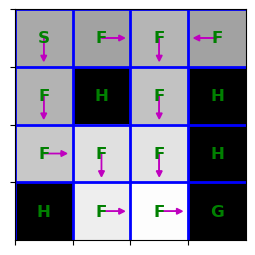

START POLICY ITERATION LOOP
iter    0   |   diff: 0.05307   |   V(start): 0.000 
iter    1   |   diff: 0.93606   |   V(start): 0.606 
iter    2   |   diff: 0.05557   |   V(start): 0.662 
iter    3   |   diff: 0.00000   |   V(start): 0.662 
Terminated
Время выполнения функции policy_iteration: 0.0012660026550292969 секунд


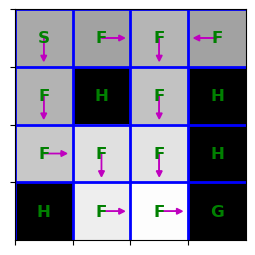

In [43]:
mdp = FrozenLakeEnv(slip_chance=0.1)

state_values_value_iter = value_iteration(mdp, gamma=0.95, num_iter=1000, min_difference=1e-05)
draw_policy(mdp, state_values_value_iter)

state_values_policy_iter, Pi_policy_iter = policy_iteration(mdp, gamma=0.95, num_iter=1000, min_difference=1e-05)
draw_policy(mdp, state_values_policy_iter, Pi_policy_iter)

<font size=5 color=green> FROZEN LAKE (LARGE)

START VALUE ITERATION LOOP
iter    0   |   diff: 0.90000   |   V(start): 0.000 
iter    1   |   diff: 0.76950   |   V(start): 0.000 
iter    2   |   diff: 0.65792   |   V(start): 0.000 
iter    3   |   diff: 0.56252   |   V(start): 0.000 
iter    4   |   diff: 0.50768   |   V(start): 0.000 
iter    5   |   diff: 0.45691   |   V(start): 0.000 
iter    6   |   diff: 0.41019   |   V(start): 0.000 
iter    7   |   diff: 0.36927   |   V(start): 0.000 
iter    8   |   diff: 0.33318   |   V(start): 0.000 
iter    9   |   diff: 0.30066   |   V(start): 0.000 
iter   10   |   diff: 0.27057   |   V(start): 0.000 
iter   11   |   diff: 0.24343   |   V(start): 0.000 
iter   12   |   diff: 0.21897   |   V(start): 0.000 
iter   13   |   diff: 0.19694   |   V(start): 0.197 
iter   14   |   diff: 0.10173   |   V(start): 0.285 
iter   15   |   diff: 0.07828   |   V(start): 0.363 
iter   16   |   diff: 0.03081   |   V(start): 0.394 
iter   17   |   diff: 0.02269   |   V(start): 0.412 
iter   18   |   dif

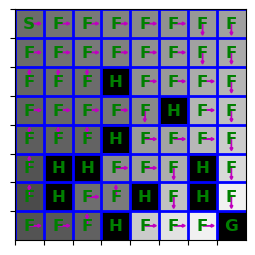

START POLICY ITERATION LOOP
iter    0   |   diff: 0.94488   |   V(start): 0.000 
iter    1   |   diff: 0.83077   |   V(start): 0.385 
iter    2   |   diff: 0.05076   |   V(start): 0.424 
iter    3   |   diff: 0.01084   |   V(start): 0.426 
iter    4   |   diff: 0.00689   |   V(start): 0.426 
iter    5   |   diff: 0.00239   |   V(start): 0.426 
iter    6   |   diff: 0.00180   |   V(start): 0.426 
iter    7   |   diff: 0.00000   |   V(start): 0.426 
Terminated
Время выполнения функции policy_iteration: 0.018501758575439453 секунд


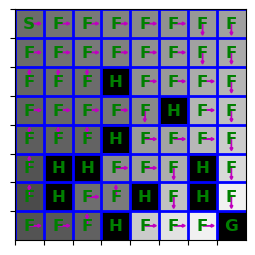

In [44]:
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)

state_values_value_iter = value_iteration(mdp, gamma=0.95, num_iter=1000, min_difference=1e-05)
draw_policy(mdp, state_values_value_iter)

state_values_policy_iter, Pi_policy_iter = policy_iteration(mdp, gamma=0.95, num_iter=1000, min_difference=1e-05)
draw_policy(mdp, state_values_policy_iter, Pi_policy_iter)

In [63]:
# Measure agent's average reward
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.33)
state_values_value_iter = value_iteration(mdp, gamma=0.95, num_iter=1000, min_difference=1e-05)
total_rewards = []

for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values_value_iter, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("Value iteration FrozenLakeLarge average reward: ", np.mean(total_rewards))

START VALUE ITERATION LOOP
iter    0   |   diff: 0.67000   |   V(start): 0.000 
iter    1   |   diff: 0.42645   |   V(start): 0.000 
iter    2   |   diff: 0.27144   |   V(start): 0.000 
iter    3   |   diff: 0.17277   |   V(start): 0.000 
iter    4   |   diff: 0.13705   |   V(start): 0.000 
iter    5   |   diff: 0.10447   |   V(start): 0.000 
iter    6   |   diff: 0.08155   |   V(start): 0.000 
iter    7   |   diff: 0.07437   |   V(start): 0.000 
iter    8   |   diff: 0.06743   |   V(start): 0.000 
iter    9   |   diff: 0.06027   |   V(start): 0.000 
iter   10   |   diff: 0.05354   |   V(start): 0.000 
iter   11   |   diff: 0.04750   |   V(start): 0.000 
iter   12   |   diff: 0.04063   |   V(start): 0.000 
iter   13   |   diff: 0.03608   |   V(start): 0.012 
iter   14   |   diff: 0.03307   |   V(start): 0.027 
iter   15   |   diff: 0.02992   |   V(start): 0.051 
iter   16   |   diff: 0.02680   |   V(start): 0.074 
iter   17   |   diff: 0.02381   |   V(start): 0.098 
iter   18   |   dif

In [64]:
# Measure agent's average reward
mdp = FrozenLakeEnv(map_name = '8x8', slip_chance=0.33)
state_values_policy_iter, Pi_policy_iter = policy_iteration(mdp, gamma=0.95, num_iter=1000, min_difference=1e-05)
total_rewards = []

for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            Pi_policy_iter[s])
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))

START POLICY ITERATION LOOP
iter    0   |   diff: 0.18792   |   V(start): 0.000 
iter    1   |   diff: 0.62475   |   V(start): 0.087 
iter    2   |   diff: 0.11752   |   V(start): 0.203 
iter    3   |   diff: 0.05861   |   V(start): 0.210 
iter    4   |   diff: 0.02711   |   V(start): 0.211 
iter    5   |   diff: 0.00092   |   V(start): 0.211 
iter    6   |   diff: 0.00000   |   V(start): 0.211 
Terminated
Время выполнения функции policy_iteration: 0.056693077087402344 секунд
average reward:  0.631


# Find an MDP for which value iteration takes long to converge  (up to 0.5 points)

When we ran value iteration on the small frozen lake problem, the last iteration where an action changed was iteration 6 -- i.e., value iteration computed the optimal policy at iteration 6. Are there any guarantees regarding how many iterations it'll take value iteration to compute the optimal policy? There are no such guarantees without additional assumptions -- we can construct the MDP in such a way that the greedy policy will change after arbitrarily many iterations.

Your task: define an MDP with at most 3 states and 2 actions, such that when you run value iteration, the optimal action changes at iteration >= 50. Use discount=0.95. (However, note that the discount doesn't matter here -- you can construct an appropriate MDP with any discount.)

Note: value function must change at least once after iteration >=50, not necessarily change on every iteration till >=50.

Note: by default `initial state` is selected randomly, you might want to change this.

<font color=red size=6> Это задание не сделал, не успел. Потом попробую.

In [47]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.7, 's1': 0.15, 's2': 0.15},
        'a1': {'s0': 0.7, 's1': 0.15, 's2': 0.15}
    },
    's1': {
        'a0': {'s0': 0.5, 's1': 0.2, 's2': 0.3},
        'a1': {'s0': 0.1, 's1': 0.2, 's2': 0.7}
    },
    's2': {
        'a0': {'s0': 0.5, 's1': 0.5, 's2': 0.0},
        'a1': {'s0': 0.5, 's1': 0.2, 's2': 0.3}
    }
}

rewards = {
    's0': {
        'a0': {'s0': 0, 's1': 0, 's2': 0},
        'a1': {'s0': 0, 's1': 1, 's2': 0}
    },
    's1': {
        'a0': {'s0': 0, 's1': 0, 's2': 0},
        'a1': {'s0': 0, 's1': 0, 's2': 0}
    },
    's2': {
        'a0': {'s0': +3, 's1': +3, 's2': +5},
        'a1': {'s0': +4, 's1': +5, 's2': +3}
    }
}


from numpy import random
# mdp = MDP(transition_probs, rewards, initial_state=random.choice(tuple(transition_probs.keys())))
mdp = MDP(transition_probs, rewards, initial_state='s0')

# Feel free to change the initial_state

In [48]:
gamma = 0.95
state_values = {s: 0 for s in mdp.get_all_states()}
policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                   for state in sorted(mdp.get_all_states())])

for i in range(100):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)

    new_policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                           for state in sorted(mdp.get_all_states())])
    
    n_changes = (policy != new_policy).sum()
    if n_changes != 0:
        print("N actions changed = %i \n" % n_changes)
    policy = new_policy

# please ignore iter 0 at each step

after iteration 0
START VALUE ITERATION LOOP
iter    0   |   diff: 3.90000   |   V(start): 0.150 
Время выполнения функции value_iteration: 4.601478576660156e-05 секунд
N actions changed = 1 

after iteration 1
START VALUE ITERATION LOOP
iter    0   |   diff: 2.47050   |   V(start): 0.771 
Время выполнения функции value_iteration: 2.5987625122070312e-05 секунд
after iteration 2
START VALUE ITERATION LOOP
iter    0   |   diff: 1.20650   |   V(start): 1.647 
Время выполнения функции value_iteration: 2.7179718017578125e-05 секунд
after iteration 3
START VALUE ITERATION LOOP
iter    0   |   diff: 0.94282   |   V(start): 2.500 
Время выполнения функции value_iteration: 4.00543212890625e-05 секунд
after iteration 4
START VALUE ITERATION LOOP
iter    0   |   diff: 0.80631   |   V(start): 3.285 
Время выполнения функции value_iteration: 2.8848648071289062e-05 секунд
after iteration 5
START VALUE ITERATION LOOP
iter    0   |   diff: 0.71577   |   V(start): 3.996 
Время выполнения функции value_

In [49]:
print('SUCCESS!')

SUCCESS!
